# Phase 8 — Notebook 2: Subword Tokenization — BPE, WordPiece & SentencePiece

> **Why This Matters**: Before a model can learn anything, text must be converted to numbers. The tokenization strategy is a critical design decision — it determines vocabulary size, how unknown words are handled, and how efficiently the model processes language.

---

## 1. Why Word-Level Tokenization Fails

The most intuitive tokenization approach is to split text into words separated by spaces. But this creates serious problems at scale:

### 🚧 Problem 1: The OOV (Out-of-Vocabulary) Problem
If a word wasn't in your training corpus, it's unseen at test time. You'd represent it as `<UNK>` — throwing away all information. Imagine reading a document and replacing every word you haven't seen before with `[UNKNOWN]`. That's exactly what word-level tokenizers do.

```
Training vocab: ["running", "run", "runner"]
Test sentence: "She was running swiftly along the riverbank"
After tokenizing: ["She", "was", "running", "swiftly", <UNK>, "the", <UNK>]
```

### 🚧 Problem 2: Vocabulary Explosion
English alone has 170,000+ words in the dictionary. Add morphological variations, compound words, proper nouns, technical terms, and multilingual text — the vocabulary becomes unmanageably large. Storing a 768-dimensional embedding for each of 500,000 words is extremely memory-inefficient.

### 🚧 Problem 3: Morphological Blindness
Word-level tokenization treats "run", "running", "runner", and "ran" as 4 completely unrelated tokens, even though they share the same root meaning. The model has to independently learn that they're semantically related.

---

In [ ]:
# Demonstrate the OOV problem with word-level tokenization
# (No external libraries needed — pure Python)

# Simulated training vocabulary (small example)
train_corpus = "the cat sat on the mat the cat is happy the mat is soft"
train_vocab = set(train_corpus.split())
print(f'Training vocabulary ({len(train_vocab)} words): {sorted(train_vocab)}\n')

# Test sentences with unseen words
test_sentences = [
    "the happy kitten sits on the floor",
    "cats are sleeping on soft mats everywhere",
    "unhappiness drove the feline away",
]

print('Word-Level Tokenization — OOV Demonstration:')
print('=' * 55)
for sent in test_sentences:
    tokens = [w if w in train_vocab else '<UNK>' for w in sent.split()]
    oov_count = tokens.count('<UNK>')
    print(f'Input:  {sent}')
    print(f'Output: {tokens}')
    print(f'Lost {oov_count}/{len(sent.split())} words ({100*oov_count//len(sent.split())}% information loss!)')
    print('-' * 55)

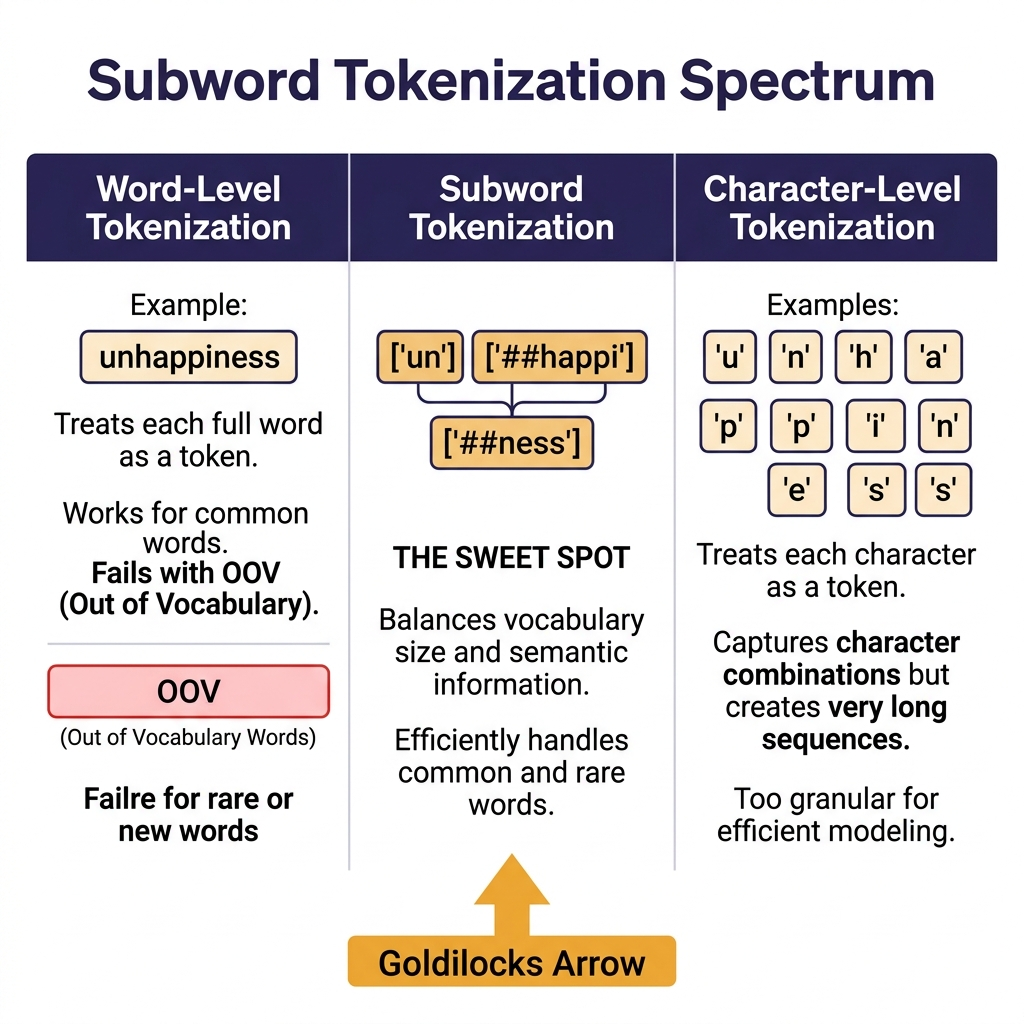

*Figure 1: The Tokenization Spectrum — Character-level (too granular), Word-level (too coarse), Subword (the sweet spot)*



## 2. The Subword Sweet Spot

The insight is to **split rare/complex words into meaningful sub-units while keeping common words as-is**.

```
"unhappiness"  →  ["un", "happi", "##ness"]   ← morphologically meaningful!
"tokenization" →  ["token", "##ization"]       ← shares root with 'token'
"the"          →  ["the"]                       ← common word stays whole
"ChatGPT"      →  ["Chat", "##G", "##PT"]      ← handles neologisms gracefully
```

This gives us:
- ✅ **No OOV**: any word can be decomposed into known subword units (last resort: individual characters)
- ✅ **Small vocabulary**: 30,000–50,000 subword tokens instead of millions of words
- ✅ **Morphological sharing**: "run", "running", "runner" all contain the "run" subword

---

## 3. Byte-Pair Encoding (BPE) — Used by GPT-2, GPT-3, RoBERTa, LLaMA

BPE was originally a data compression algorithm. Sennrich et al. (2016) adapted it for NLP tokenization. The algorithm is elegant:

1. **Initialize** vocabulary with all individual characters
2. **Count** all adjacent symbol pairs in the training corpus
3. **Merge** the most frequent pair into a new symbol
4. **Repeat** steps 2-3 until vocabulary reaches the target size

The result is a vocabulary learned directly from the data — frequent subwords are preserved whole, rare ones stay split.

---

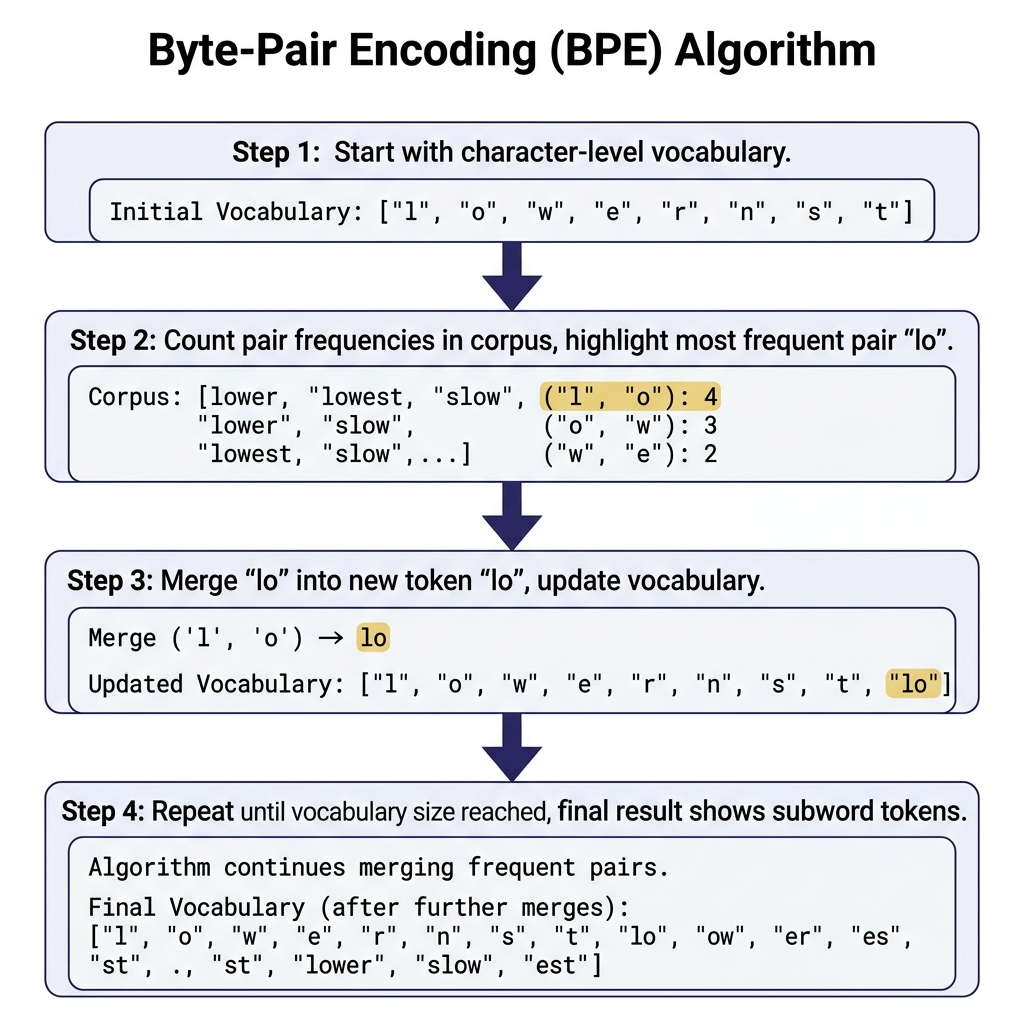

*Figure 2: The BPE Merge Algorithm — Iteratively merging the most frequent character pairs*

In [ ]:
# BPE Algorithm — Implemented From Scratch
from collections import Counter, defaultdict
import re

def get_vocab(corpus):
    """Convert corpus to word frequency counts with character-level spacing."""
    vocab = Counter()
    for word in corpus.split():
        # Represent each word as space-separated characters + </w> end marker
        vocab[' '.join(list(word)) + ' </w>'] += 1
    return vocab

def get_stats(vocab):
    """Count frequency of each consecutive pair in the vocabulary."""
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_vocab(best_pair, vocab):
    """Merge the best pair in all words in the vocabulary."""
    new_vocab = {}
    bigram = re.escape(' '.join(best_pair))
    pattern = re.compile(r'(?<! )' + bigram + r'(?! )')
    for word, freq in vocab.items():
        new_word = pattern.sub(''.join(best_pair), word)
        new_vocab[new_word] = freq
    return new_vocab

# Example corpus
corpus = 'low low low low low lower lower newest newest newest newest widest widest widest'
vocab = get_vocab(corpus)

print('Initial Character-Level Vocabulary:')
print('-' * 45)
for word, freq in vocab.items():
    print(f'  {freq:2d}x  [{word}]')

print('\n🔄 Running BPE Merge Operations...')
print('=' * 55)

num_merges = 10
for i in range(num_merges):
    pairs = get_stats(vocab)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    vocab = merge_vocab(best, vocab)
    print(f'Merge {i+1:2d}: ("{best[0]}" + "{best[1]}") → "{best[0]+best[1]}"  (freq={pairs[best]})')

print('\nFinal Vocabulary After BPE:')
print('-' * 45)
for word, freq in sorted(vocab.items(), key=lambda x: -x[1]):
    print(f'  {freq:2d}x  [{word}]')

## 4. WordPiece — Used by BERT, DistilBERT, ALBERT

WordPiece is similar to BPE but uses a different criterion for deciding which pairs to merge:

- **BPE**: merges the pair with **highest frequency**
- **WordPiece**: merges the pair that **maximizes the likelihood** of the training corpus (maximizes language model probability)

In practice, this leads to slightly different tokenizations. WordPiece uses the `##` prefix to denote continuation subwords:

```
'unaffordable'  →  ['un', '##afford', '##able']
                        ↑       ↑           ↑
                    start  continuation  continuation
```

### Special Tokens in BERT
BERT uses 5 special tokens with specific roles:

| Token | Meaning | Usage |
|---|---|---|
| `[CLS]` | Classification | First token of every sequence; its output = sentence embedding |
| `[SEP]` | Separator | Marks boundary between two sentences |
| `[MASK]` | Masked token | Replaces tokens during masked language model pre-training |
| `[PAD]` | Padding | Fills shorter sequences to match batch length |
| `[UNK]` | Unknown | Fallback for any token not in vocabulary |

---

In [ ]:
# Demonstrate BERT's WordPiece tokenizer
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Test sentences — variety of word types
test_words = [
    'unhappiness',
    'tokenization',
    'ChatGPT',
    'coronavirus',
    'photosynthesis',
    'transformer',
    'autoregressive',
    'supercalifragilisticexpialidocious',
]

print('BERT WordPiece Tokenization Results:')
print('=' * 60)
for word in test_words:
    tokens = tokenizer.tokenize(word)
    print(f'{word:<35} →  {tokens}')

# Full sentence tokenization with special tokens
print('\n' + '=' * 60)
print('Full Sentence Pair with Special Tokens:')
print('=' * 60)
sent_a = 'The cat sat on the mat.'
sent_b = 'It was a very comfortable mat.'
encoding = tokenizer(sent_a, sent_b, return_tensors='pt', padding=True)

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
seg_ids = encoding['token_type_ids'][0].tolist()
print(f'\nSentence A: "{sent_a}"')
print(f'Sentence B: "{sent_b}"\n')
print(f'{"Token":<25} {"Segment":<10} {"Role"}')
print('-' * 55)
for tok, seg in zip(tokens, seg_ids):
    role = ''
    if tok == '[CLS]': role = '← Sentence-level representation'
    elif tok == '[SEP]': role = '← Sentence boundary marker'
    elif tok.startswith('##'): role = '← WordPiece continuation'
    sent_label = 'Sentence A' if seg == 0 else 'Sentence B'
    print(f'{tok:<25} {sent_label:<10} {role}')

## 5. SentencePiece — Used by T5, LLaMA, Mistral, ALBERT

SentencePiece is a language-agnostic tokenizer that works directly on raw text without any pre-tokenization (no splitting on spaces first). This makes it particularly useful for:

- Languages without clear word boundaries (Chinese, Japanese)
- Mixed-script text
- Models that need to handle code, URLs, and special characters

Key properties:
- Treats spaces as regular characters (represented as `▁`)
- Uses the Unigram Language Model algorithm or BPE underneath
- Completely deterministic and reversible tokenization

```
SentencePiece encoding of 'Hello World':
  → ['▁Hello', '▁World']   (▁ represents a leading space)
```

---

## 6. Side-by-Side Tokenizer Comparison

Let's compare how GPT-2's BPE and BERT's WordPiece tokenize the same text:

---

In [ ]:
from transformers import GPT2Tokenizer, BertTokenizer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

bert_tok = BertTokenizer.from_pretrained('bert-base-uncased')
gpt2_tok = GPT2Tokenizer.from_pretrained('gpt2')

test_sentences = [
    'The Transformer architecture revolutionized NLP in 2017.',
    'Unhappiness stems from unfulfilled expectations.',
    'GPT-4 was trained on approximately 1 trillion tokens.',
    'She photographed the microorganisms under the microscope.',
]

print('Tokenizer Comparison: BERT (WordPiece) vs GPT-2 (BPE)')
print('=' * 70)
for sent in test_sentences:
    bert_tokens = bert_tok.tokenize(sent)
    gpt2_tokens = gpt2_tok.tokenize(sent)
    print(f'\nInput: "{sent}"')
    print(f'BERT  ({len(bert_tokens):2d} tokens): {bert_tokens}')
    print(f'GPT-2 ({len(gpt2_tokens):2d} tokens): {gpt2_tokens}')

# Vocabulary size comparison
print('\n' + '=' * 70)
print('Vocabulary Statistics:')
print(f'  BERT  (bert-base-uncased): {bert_tok.vocab_size:,} tokens')
print(f'  GPT-2:                     {gpt2_tok.vocab_size:,} tokens')
print('\nKey Observation:')
print('  BERT uses ## prefix for subword continuations.')
print('  GPT-2 uses Ġ prefix to mark tokens that follow a space.')
print('  Both handle unknown words by splitting into smaller units — no OOV!')

## 7. Summary — Why Tokenization Design Matters

| Design Choice | Impact on Model |
|---|---|
| **Vocabulary size** | Larger vocab = fewer tokens per sentence, but larger embedding matrix |
| **BPE vs WordPiece** | Slightly different splits; WordPiece tends to be more linguistically motivated |
| **Special tokens** | `[CLS]` enables classification; `[SEP]` enables two-sequence tasks |
| **Case sensitivity** | `bert-base-uncased` lowercases all text; `bert-base-cased` preserves case (better for NER) |
| **Max sequence length** | BERT is limited to 512 tokens; GPT-2 to 1024 — determines what fits in one pass |

### 🚀 What's Next
Now that we understand how text becomes tokens, Notebook 3 dives into the **pre-training objectives** — the self-supervised tasks that teach BERT and GPT to understand and generate language.

---
*Phase 8, Notebook 2 of 10 — NLP From Scratch: Foundation to Advanced*